Importing packages

In [21]:
import cv2
import os
import random
import shutil
import matplotlib.pyplot as plt

In [ ]:
def display_image_with_bounding_boxes(image_path, bounding_box_path):
    # Paths
    IMAGE_PATH = image_path
    BOUNDING_BOX_PATH = bounding_box_path

    # Load the image
    image = cv2.imread(IMAGE_PATH)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    img_height, img_width, _ = image.shape

    # Load the labels
    with open(BOUNDING_BOX_PATH, 'r') as f:
        lines = f.readlines()

    # Draw bounding boxes
    for line in lines:
        parts = line.strip().split()
        class_id = int(parts[0])
        x_center = float(parts[1])
        y_center = float(parts[2])
        width = float(parts[3])
        height = float(parts[4])

        # Convert normalized coordinates to pixel coordinates
        x_center *= img_width
        y_center *= img_height
        width *= img_width
        height *= img_height

        # Calculate top-left and bottom-right corners
        x1 = int(x_center - width / 2)
        y1 = int(y_center - height / 2)
        x2 = int(x_center + width / 2)
        y2 = int(y_center + height / 2)

        # Clamp coordinates to image boundaries
        x1 = max(0, x1)
        y1 = max(0, y1)
        x2 = min(img_width - 1, x2)
        y2 = min(img_height - 1, y2)

        # Draw rectangle
        cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)

        # Put class label
        cv2.putText(
            image,
            f"Class {class_id}",
            (x1, y1 - 5),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 255, 0),
            1,
        )   
    h, w, _ = image.shape

    plt.figure(figsize=(w/100, h/100), dpi=100)
    plt.imshow(image)
    plt.axis("off")
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
    plt.show()

In [ ]:
def create_YOLO_ready_data_distribution(root):
    ROOT_DIR = root
    IMAGES_DIR = os.path.join(ROOT_DIR, 'images')
    LABELS_DIR = os.path.join(ROOT_DIR, 'labels')

    # Create proper YOLO folders
    for split in ['train', 'val', 'test']:
        os.makedirs(os.path.join(ROOT_DIR, 'images', split), exist_ok=True)
        os.makedirs(os.path.join(ROOT_DIR, 'labels', split), exist_ok=True)

    # Get all images
    images = [f for f in os.listdir(IMAGES_DIR) if f.endswith(('.jpg', '.png'))]

    # Shuffle
    random.seed(1)
    random.shuffle(images)

    # Split 80% train, 20% val
    split_index = int(0.8 * len(images))
    train_images = images[:split_index]
    val_images = images[split_index:]

    def move_files(file_list, split):
        for img_file in file_list:
            label_file = img_file.rsplit(".", 1)[0] + ".txt"

            # Move image
            shutil.move(
                os.path.join(IMAGES_DIR, img_file),
                os.path.join(ROOT_DIR, 'images', split, img_file)
            )

            # Move corresponding label
            shutil.move(
                os.path.join(LABELS_DIR, label_file),
                os.path.join(ROOT_DIR, 'labels', split, label_file)
            )

    move_files(train_images, 'train')
    move_files(val_images, 'val')

    print(f"Moved {len(train_images)} images to train set and {len(val_images)} images to val set.")

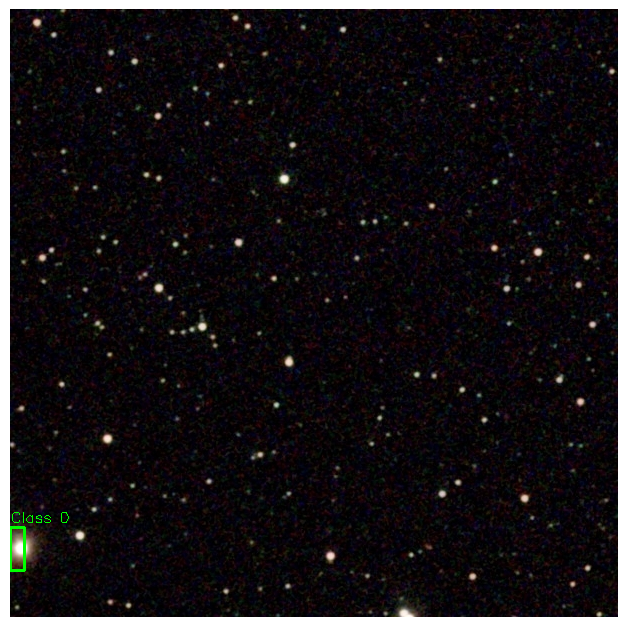

In [20]:
display_image_with_bounding_boxes('Data/DeepSpaceYoloDataSet/images/5.jpg', 'Data/DeepSpaceYoloDataSet/labels/5.txt')

In [23]:
create_YOLO_ready_data_distribution('Data/DeepSpaceYoloDataSet')

FileNotFoundError: [WinError 3] The system cannot find the path specified